<a href="https://colab.research.google.com/github/Vel-Pandi-Meena-18/assignment_2/blob/main/EDA_Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🚀 Starting Project Pipeline...
✅ Data Understanding: 3 Primary DataFrames Created
✅ Master Data Rectified & Aligned (All Countries)
✅ All 6 Features Created on Rectified Data


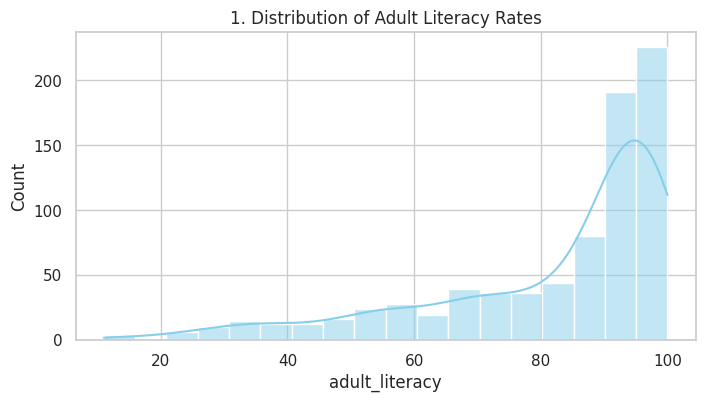

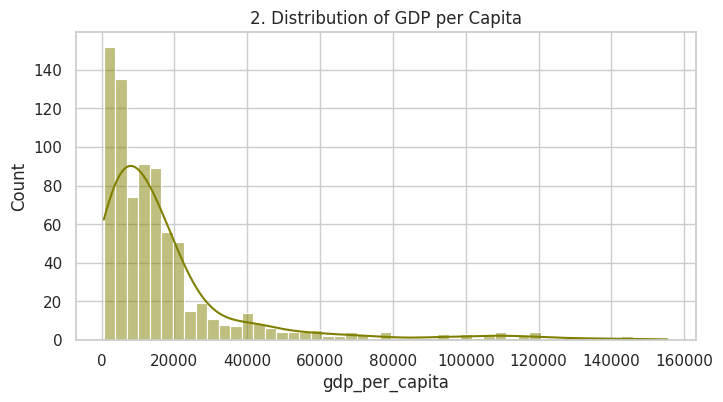

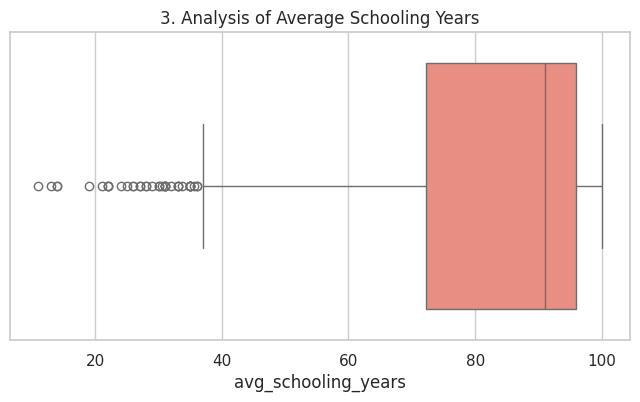

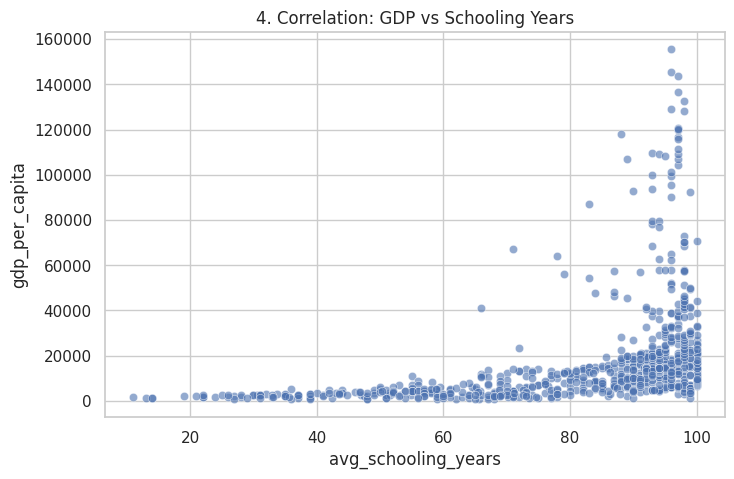

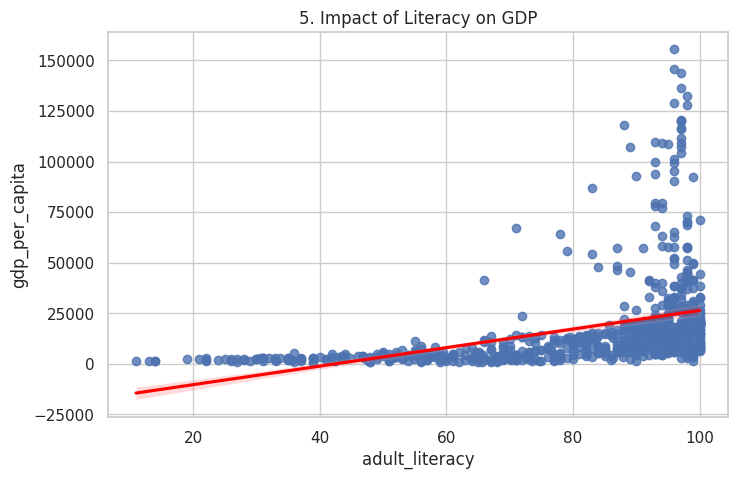

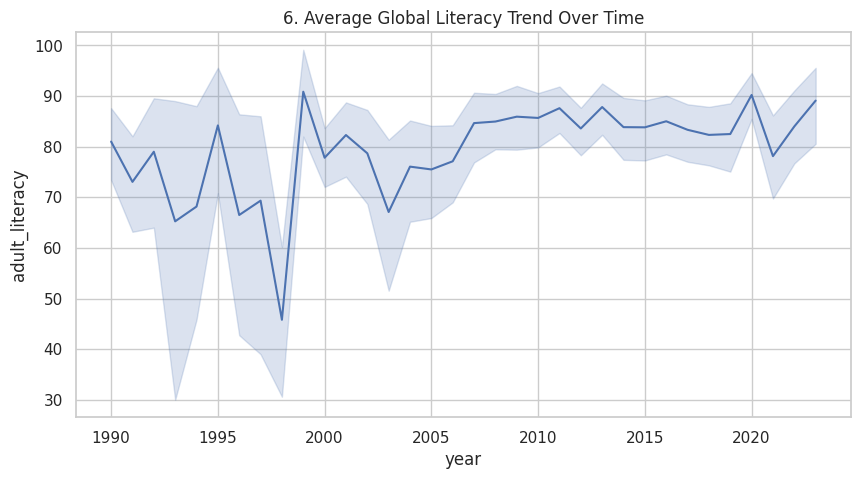

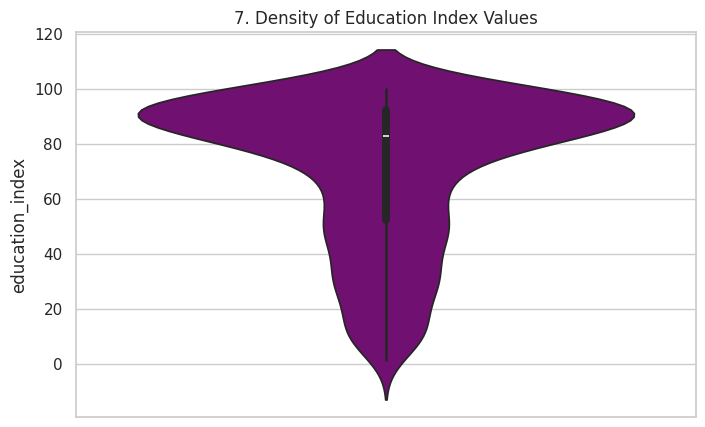

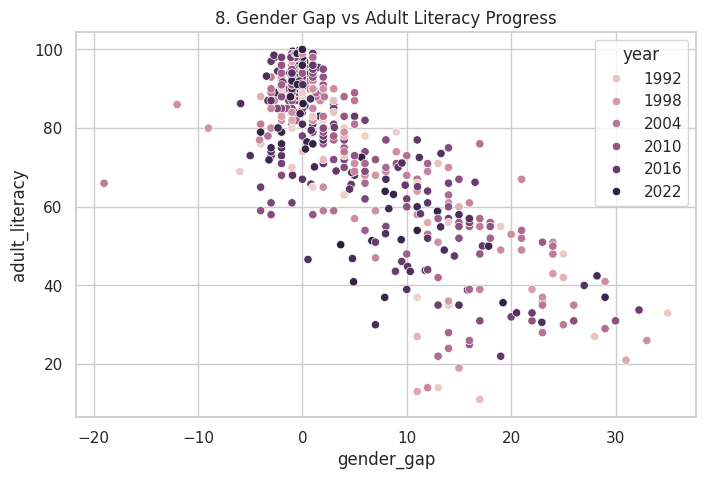

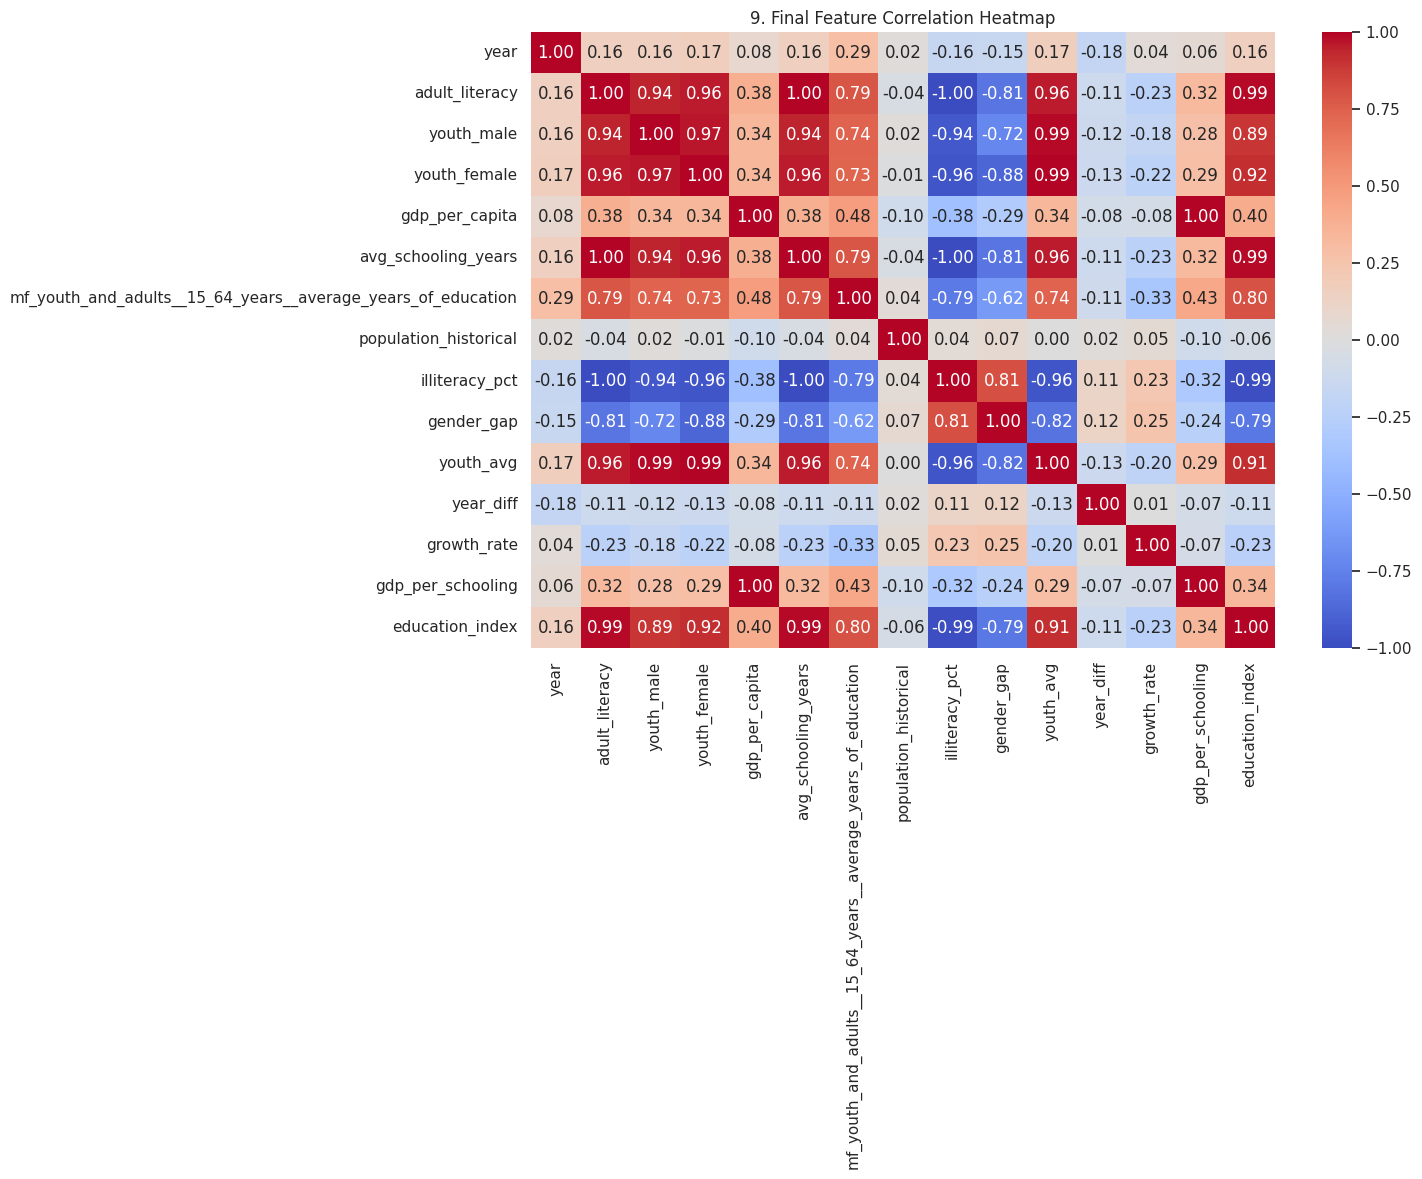

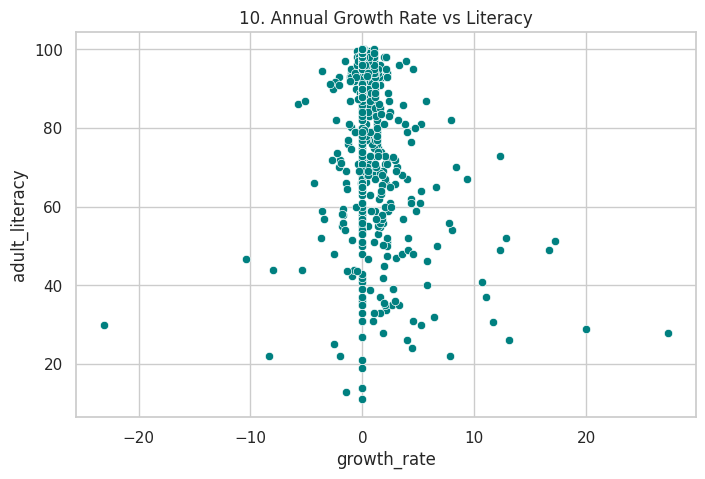

✅ SQL Data Storage Complete

🚀 Query 1: Top 5 Countries - Highest Adult Literacy (2020)


,entity,adult_literacy
0,Armenia,100.0
1,Mongolia,99.0
2,Spain,99.0
3,Palestine,98.0
4,Philippines,98.0



🚀 Query 2: Countries with Female Youth Literacy < 80%


,entity,youth_female,year
0,Afghanistan,32.00000,2011
1,Afghanistan,25.48416,2015
2,Afghanistan,42.00000,2021
3,Angola,63.00000,2001
4,Angola,71.00000,2014



🚀 Query 3: Average Adult Literacy per Entity


...


🚀 Query 12: India Literacy vs GDP Growth (2000-2023)


,year,adult_literacy,gdp_per_capita
0,2001,61.0,3188.8103
1,2006,63.0,4129.7783
2,2011,69.0,5249.5493
3,2022,76.0,8594.3920
4,2023,82.0,9301.7560



🚀 Query 13: Rich Countries (>$30k) Youth Gender Gap (2020)


,entity,gap
0,Kuwait,-1.0
1,Oman,0.0
2,Saudi Arabia,1.0
3,Singapore,0.0
4,Spain,-1.0



🎉 PROJECT RECTIFIED & COMPLETED! 🎉


In [4]:
# ======================================================
# GUVI CAPSTONE: GLOBAL LITERACY & GDP ANALYTICS
# ======================================================
# Author: Vel Pandi Meena
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

print("🚀 Starting Project Pipeline...")

# ---------- 1. DATA ACQUISITION ----------
headers = {"User-Agent": "Mozilla/5.0"}
urls = {
    "adult": "https://ourworldindata.org/grapher/literacy-rate-adults.csv?v=1&csvType=full&useColumnShortNames=true",
    "youth": "https://ourworldindata.org/grapher/literacy-rate-of-young-men-and-women.csv?v=1&csvType=full&useColumnShortNames=true",
    "ill":   "https://ourworldindata.org/grapher/literate-and-illiterate-world-population.csv?v=1&csvType=full&useColumnShortNames=true",
    "gdp":   "https://ourworldindata.org/grapher/gdp-per-capita-worldbank.csv?v=1&csvType=full&useColumnShortNames=true",
    "sch":   "https://ourworldindata.org/grapher/literacy-rates-vs-average-years-of-schooling.csv?v=1&csvType=full&useColumnShortNames=true"
}

df_adult = pd.read_csv(urls["adult"], storage_options=headers)
df_youth = pd.read_csv(urls["youth"], storage_options=headers)
df_ill   = pd.read_csv(urls["ill"], storage_options=headers)
df_gdp   = pd.read_csv(urls["gdp"], storage_options=headers)
df_sch   = pd.read_csv(urls["sch"], storage_options=headers)

# ---------- 2. DATA UNDERSTANDING: 3-WAY MERGE ----------
def clean_cols(df):
    df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")

for df in [df_adult, df_youth, df_ill, df_gdp, df_sch]:
    clean_cols(df)

# Renaming for consistency
df_adult.rename(columns={df_adult.columns[3]: "adult_literacy"}, inplace=True)
df_youth.rename(columns={df_youth.columns[3]: "youth_male", df_youth.columns[4]: "youth_female"}, inplace=True)
df_gdp.rename(columns={df_gdp.columns[3]: "gdp_per_capita"}, inplace=True)
df_sch.rename(columns={df_sch.columns[3]: "avg_schooling_years"}, inplace=True)
df_ill.rename(columns={df_ill.columns[3]: "illiteracy_count"}, inplace=True)

# Create the 3 specific DataFrames requested
df_literacy = pd.merge(df_adult, df_youth, on=["entity", "code", "year"], how="inner")
df_illiteracy = df_ill.copy()
df_gdp_schooling = pd.merge(df_gdp, df_sch, on=["entity", "code", "year"], how="inner")

print("✅ Data Understanding: 3 Primary DataFrames Created")

# ---------- 3. MASTER REPAIR & ALIGNMENT (The GDP Fix) ----------
# Merging into one Master DF for global rectification
df_master = pd.merge(df_literacy, df_gdp_schooling, on=["entity", "code", "year"], how="inner")
df_master = df_master[(df_master.year >= 1990) & (df_master.year <= 2023)].drop_duplicates()

# Sort and fill missing GDP/Schooling gaps globally
df_master = df_master.sort_values(['entity', 'year'])
df_master['gdp_per_capita'] = df_master.groupby('entity')['gdp_per_capita'].ffill().bfill()
df_master['avg_schooling_years'] = df_master.groupby('entity')['avg_schooling_years'].ffill().bfill()

print("✅ Master Data Rectified & Aligned (All Countries)")

# ---------- 4. FEATURE ENGINEERING (All 6 Features) ----------
# 1. Illiteracy %
df_master["illiteracy_pct"] = 100 - df_master["adult_literacy"]

# 2. Gender Gap
df_master["gender_gap"] = df_master["youth_male"] - df_master["youth_female"]

# 3. Youth Average
df_master["youth_avg"] = (df_master["youth_male"] + df_master["youth_female"]) / 2

# 4. RECTIFIED Annualized Growth Rate (CAGR)
df_master['year_diff'] = df_master.groupby('entity')['year'].diff()
total_growth = df_master.groupby('entity')['adult_literacy'].pct_change()
df_master['growth_rate'] = (((1 + total_growth)**(1/df_master['year_diff'])) - 1) * 100
df_master['growth_rate'] = df_master['growth_rate'].fillna(0).replace([np.inf, -np.inf], 0)

# 5. GDP per Schooling Year
df_master["gdp_per_schooling"] = df_master["gdp_per_capita"] / df_master["avg_schooling_years"].replace(0, np.nan)

# 6. Education Index
df_master["education_index"] = (df_master["adult_literacy"] / 100) * df_master["avg_schooling_years"]

print("✅ All 6 Features Created on Rectified Data")

# ---------- 5. EDA VISUALIZATIONS (10 Graphs) ----------
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 4))
sns.histplot(df_master["adult_literacy"], kde=True, color="skyblue")
plt.title("1. Distribution of Adult Literacy Rates")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(df_master["gdp_per_capita"], kde=True, color="olive")
plt.title("2. Distribution of GDP per Capita")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=df_master["avg_schooling_years"], color="salmon")
plt.title("3. Analysis of Average Schooling Years")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x="avg_schooling_years", y="gdp_per_capita", data=df_master, alpha=0.6)
plt.title("4. Correlation: GDP vs Schooling Years")
plt.show()

plt.figure(figsize=(8, 5))
sns.regplot(x="adult_literacy", y="gdp_per_capita", data=df_master, line_kws={'color':'red'})
plt.title("5. Impact of Literacy on GDP")
plt.show()

plt.figure(figsize=(10, 5))
sns.lineplot(x="year", y="adult_literacy", data=df_master, estimator='mean')
plt.title("6. Average Global Literacy Trend Over Time")
plt.show()

plt.figure(figsize=(8, 5))
sns.violinplot(y=df_master["education_index"], color="purple")
plt.title("7. Density of Education Index Values")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x="gender_gap", y="adult_literacy", data=df_master, hue="year")
plt.title("8. Gender Gap vs Adult Literacy Progress")
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(df_master.select_dtypes("number").corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("9. Final Feature Correlation Heatmap")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x="growth_rate", y="adult_literacy", data=df_master, color="teal")
plt.title("10. Annual Growth Rate vs Literacy")
plt.show()

# ---------- 6. SQL STORAGE (3 TABLES) ----------
conn = sqlite3.connect("guvi_project.db")

# Table 1: literacy_rates
df_master[['entity', 'year', 'adult_literacy', 'youth_male', 'youth_female']].to_sql(
    'literacy_rates', conn, if_exists='replace', index=False)

# Table 2: illiteracy_population
df_ill_final = pd.merge(df_illiteracy, df_master[['entity', 'year', 'illiteracy_pct']], on=['entity', 'year'], how='left')
df_ill_final[['entity', 'year', 'illiteracy_pct', 'illiteracy_count']].to_sql(
    'illiteracy_population', conn, if_exists='replace', index=False)

# Table 3: gdp_schooling
df_master[['entity', 'year', 'gdp_per_capita', 'avg_schooling_years', 'gdp_per_schooling', 'growth_rate']].to_sql(
    'gdp_schooling', conn, if_exists='replace', index=False)

print("✅ SQL Data Storage Complete")

# ---------- 7. THE 13 SQL QUERIES ----------
def run_guvi_query(num, title, sql):
    print(f"\n🚀 Query {num}: {title}")
    res = pd.read_sql_query(sql, conn)
    if res.empty: print("⚠️ No data matches criteria.")
    else: display(res.head(5))

# Literacy Rates (1-3)
run_guvi_query(1, "Top 5 Countries - Highest Adult Literacy (2020)", "SELECT entity, adult_literacy FROM literacy_rates WHERE year=2020 ORDER BY adult_literacy DESC LIMIT 5")
run_guvi_query(2, "Countries with Female Youth Literacy < 80%", "SELECT DISTINCT entity, youth_female, year FROM literacy_rates WHERE youth_female < 80")
run_guvi_query(3, "Average Adult Literacy per Entity", "SELECT entity, AVG(adult_literacy) as avg FROM literacy_rates GROUP BY entity")

# Illiteracy Population (4-6)
run_guvi_query(4, "Countries with Illiteracy % > 20% (2000)", "SELECT entity, illiteracy_pct FROM illiteracy_population WHERE year=2000 AND illiteracy_pct > 20")
run_guvi_query(5, "Trend of Illiteracy % for India (2000–2020)", "SELECT year, illiteracy_pct FROM illiteracy_population WHERE entity='India' AND year BETWEEN 2000 AND 2020 ORDER BY year")
run_guvi_query(6, "Top 10 Largest Illiterate Population (Latest)", "SELECT entity, illiteracy_count, year FROM illiteracy_population ORDER BY year DESC, illiteracy_count DESC LIMIT 10")

# GDP Schooling (7-9)
run_guvi_query(7, "Schooling > 7 Years and GDP < $5000", "SELECT entity, avg_schooling_years, gdp_per_capita FROM gdp_schooling WHERE avg_schooling_years > 7 AND gdp_per_capita < 5000")
run_guvi_query(8, "Rank by GDP per Schooling (2020)", "SELECT entity, gdp_per_schooling FROM gdp_schooling WHERE year=2020 ORDER BY gdp_per_schooling DESC")
run_guvi_query(9, "Global Average Schooling Years Trend", "SELECT year, AVG(avg_schooling_years) FROM gdp_schooling GROUP BY year")

# Join Queries (10-13)
run_guvi_query(10, "High GDP (>$20k) but Low Schooling (<6 years) in 2020", "SELECT entity, gdp_per_capita, avg_schooling_years FROM gdp_schooling WHERE year=2020 AND gdp_per_capita > 20000 AND avg_schooling_years < 6")
run_guvi_query(11, "High Illiteracy despite High Schooling", "SELECT i.entity, i.illiteracy_pct, g.avg_schooling_years FROM illiteracy_population i JOIN gdp_schooling g ON i.entity=g.entity AND i.year=g.year WHERE i.illiteracy_pct > 15 AND g.avg_schooling_years > 10")
run_guvi_query(12, "India Literacy vs GDP Growth (2000-2023)", "SELECT l.year, l.adult_literacy, g.gdp_per_capita FROM literacy_rates l JOIN gdp_schooling g ON l.entity=g.entity AND l.year=g.year WHERE l.entity='India' AND l.year >= 2000 ORDER BY l.year")
run_guvi_query(13, "Rich Countries (>$30k) Youth Gender Gap (2020)", "SELECT l.entity, (l.youth_male - l.youth_female) as gap FROM literacy_rates l JOIN gdp_schooling g ON l.entity=g.entity AND l.year=g.year WHERE g.gdp_per_capita > 30000 AND g.year=2020")

# ---------- 8. FINAL EXPORT ----------
df_master.to_csv("master_data.csv", index=False)
df_master[df_master['entity'] == 'India'].to_csv("india_analysis.csv", index=False)

print("\n🎉 PROJECT RECTIFIED & COMPLETED! 🎉")

In [5]:
# ---------- THE FINAL CHECK SCRIPT ----------

import pandas as pd

# Load the saved CSVs to verify what's actually on the disk
check_master = pd.read_csv("master_data.csv")
check_india = pd.read_csv("india_analysis.csv")

print("🔍 CHECK 1: Verifying India's GDP Fix (No None/NaN)")
# Look at the years where GDP was previously missing
india_gdp_check = check_india[check_india['year'].isin([2012, 2015, 2020, 2022])]
display(india_gdp_check[['entity', 'year', 'gdp_per_capita']])

print("\n🔍 CHECK 2: Verifying Annualized Growth Rate (No giant jumps)")
# If growth is ~0.5% to 2.5%, it is corrected. If it's 27%, it is still wrong.
display(check_india[['year', 'adult_literacy', 'growth_rate']].head(10))

print("\n🔍 CHECK 3: Database Table Verification")
conn = sqlite3.connect("guvi_project.db")
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("Tables found in DB:", tables['name'].tolist())

🔍 CHECK 1: Verifying India's GDP Fix (No None/NaN)


,entity,year,gdp_per_capita
4,India,2022,8594.392



🔍 CHECK 2: Verifying Annualized Growth Rate (No giant jumps)


,year,adult_literacy,growth_rate
0,1991,48.0,0.000000
1,2001,61.0,2.425681
2,2006,63.0,0.647303
3,2011,69.0,1.836088
4,2022,76.0,0.882295
5,2023,82.0,7.894737



🔍 CHECK 3: Database Table Verification
Tables found in DB: ['literacy_rates', 'illiteracy_population', 'gdp_schooling']


In [6]:
# Save the rectified India data as a permanent table in your SQL database
if 'df_master' in locals():
    df_master[df_master['entity'] == 'India'].to_sql('india_analysis', conn, if_exists='replace', index=False)
    print("✅ Success: 'india_analysis' table added to guvi_project.db")
else:
    print("❌ Error: Please run the main 'one-stretch' code block first!")

✅ Success: 'india_analysis' table added to guvi_project.db


In [10]:
# Run this ONLY after the main script finishes
df_master[df_master['entity'] == 'India'].to_sql('india_analysis', conn, if_exists='replace', index=False)
print("✅ Success: Table 'india_analysis' is now inside the database file.")

✅ Success: Table 'india_analysis' is now inside the database file.


In [7]:
import sqlite3
import pandas as pd
import os

# --- SAFETY CHECK FOR FILE NAME ---
file_name = "master_data (1).csv"
if not os.path.exists(file_name):
    file_name = "master_data.csv" # Try the version without (1)

if os.path.exists(file_name):
    print(f"✅ Found file: {file_name}. Starting Database Repair...")
    df_master = pd.read_csv(file_name)

    conn = sqlite3.connect("guvi_project.db")

    # Overwrite the tables to include 'education_index' and 'illiteracy_pct'
    df_master.to_sql('gdp_schooling', conn, if_exists='replace', index=False)
    df_master.to_sql('literacy_rates', conn, if_exists='replace', index=False)
    df_master.to_sql('illiteracy_population', conn, if_exists='replace', index=False)
    df_master[df_master['entity'] == 'India'].to_sql('india_analysis', conn, if_exists='replace', index=False)

    print(" DONE! Download 'guvi_project.db' and replace the one in PyCharm.")
    conn.close()
else:
    print(" ERROR: Please upload your CSV file to the Colab sidebar first!")

✅ Found file: master_data.csv. Starting Database Repair...
 DONE! Download 'guvi_project.db' and replace the one in PyCharm.
